In [27]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as seaborn

# Download latest version
path = kagglehub.dataset_download("yasserh/housing-prices-dataset")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\Admin\.cache\kagglehub\datasets\yasserh\housing-prices-dataset\versions\1


In [28]:
df = pd.read_csv(path+'\\Housing.csv')


### A) Быстрый обзор данных (Pandas)
- df.head(), df.tail(), df.shape.
- df.info() и df.describe() (отдельно покажите .describe(include="object") для строк).
- Проверки качества: isnull().sum(), поиск дубликатов, проверка адекватности типов данных.

In [29]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [30]:
df.tail()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished
544,1750000,3850,3,1,2,yes,no,no,no,no,0,no,unfurnished


In [31]:
df.shape

(545, 13)

In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [33]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [34]:
df.describe(include="object")

,mainroad,guestroom,basement,hotwaterheating,airconditioning,prefarea,furnishingstatus
count,545,545,545,545,545,545,545
unique,2,2,2,2,2,2,3
top,yes,no,no,no,no,no,semi-furnished
freq,468,448,354,520,373,417,227


In [35]:
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [36]:
df.duplicated().sum()

np.int64(0)

In [37]:
df.dtypes

price                int64
area                 int64
bedrooms             int64
bathrooms            int64
stories              int64
mainroad            object
guestroom           object
basement            object
hotwaterheating     object
airconditioning     object
parking              int64
prefarea            object
furnishingstatus    object
dtype: object

### C) Расширенная статистика
- Для числовых колонок выведите: min, max, mean, median, mode.
- Посчитайте percentile/quantile (например, 5, 25, 50, 75, 95 перцентили).
- 🧠 Самостоятельно изучите и посчитайте: дисперсию (variance), асимметрию (skewness) и эксцесс (kurtosis). Попробуйте объяснить, что они значат для ваших данных.

In [38]:
for col in df.select_dtypes(include='number').columns:
    mode_result = df[col].mode()
    if not mode_result.empty:
        mode_value = mode_result[0]
    else:
        mode_value = 'None'
    
    print(f"{col}: min={df[col].min()}, max={df[col].max()}, mode={mode_value}, mean={df[col].mean():.2f}, median={df[col].median()}")

price: min=1750000, max=13300000, mode=3500000, mean=4766729.25, median=4340000.0
area: min=1650, max=16200, mode=6000, mean=5150.54, median=4600.0
bedrooms: min=1, max=6, mode=3, mean=2.97, median=3.0
bathrooms: min=1, max=4, mode=1, mean=1.29, median=1.0
stories: min=1, max=4, mode=2, mean=1.81, median=2.0
parking: min=0, max=3, mode=0, mean=0.69, median=0.0


In [39]:
df.select_dtypes(include='number').describe(percentiles=[.05, .25, .5, .75, .95])

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
5%,2.450000e+06,2562.000000,2.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
95%,8.400000e+06,9000.000000,4.000000,2.000000,4.000000,2.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [40]:
num_cols = ['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'parking']

stats = pd.DataFrame({
    'variance': df[num_cols].var(),
    'skewness': df[num_cols].skew(),
    'kurtosis': df[num_cols].kurtosis()
})
print(stats.round(2))

               variance  skewness  kurtosis
price      3.498544e+12      1.21      1.96
area       4.709512e+06      1.32      2.75
bedrooms   5.400000e-01      0.50      0.73
bathrooms  2.500000e-01      1.59      2.16
stories    7.500000e-01      1.08      0.68
parking    7.400000e-01      0.84     -0.57


### Дисперсия (Variance) — мера разброса
Формула: средний квадрат отклонений от среднего

показывает насколько данные "размазаны" вокруг среднего

- Большая	    Данные сильно разбросаны
- Маленькая	Данные кучно, близки к среднему
### Асимметрия (Skewness) — мера несимметричности
показывает куда "смотрит" длинный хвост распределения


- = 0	        Симметричное	Нормальное распределение
- больше 0	        Правосторонняя	Хвост справа (много маленьких значений, редкие большие)
- < 0	        Левосторонняя	Хвост слева (много больших значений, редкие маленькие)


|skew| < 0.5 — примерно симметрично

0.5 < |skew| < 1 — умеренная асимметрия

|skew| > 1 — сильная асимметрия

### Эксцесс (Kurtosis) — мера "толщины хвостов"

показывает насколько часто встречаются выбросы

- kurtosis > 1 — много выбросов

- kurtosis < -1 — почти нет выбросов, распределение "плоское"


Метрика  	Что измеряет 	Что важно для EDA

Variance	Разброс	        Нужна ли нормализация

Skewness	Симметричность	Нужно ли преобразование (log, sqrt)

Kurtosis	Выбросы     	Насколько "опасны" экстремальные значения


### D) Фичи: Энкодинг и Инжиниринг (Feature Engineering)
- Сделайте кодирование категорий: OneHotEncoder (или pd.get_dummies) — обязательно.
- Если уместно: Label Encoding или Target Encoding. Покажите датафрейм до/после.
- попробуйте применить Feature Hashing (Hashing Encoder) для признаков с большим числом уникальных значений.
- Генерация новых фич: создайте 2-3 новых признака. Например, перемножьте/поделите две существующие колонки, вытащите месяц из даты или сгруппируйте редкие категории в одну "Other".

In [41]:
print(df.shape)
print(df[['price', 'mainroad', 'furnishingstatus']].head(2))

(545, 13)
      price mainroad furnishingstatus
0  13300000      yes        furnished
1  12250000      yes        furnished


In [42]:
cat_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 
            'airconditioning', 'prefarea', 'furnishingstatus']

df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

In [43]:
# Новые признаки
df['total_rooms'] = df['bedrooms'] + df['bathrooms']
df['rooms_per_story'] = df['bedrooms'] / df['stories']
df['area_per_room'] = df['area'] / df['bedrooms']

In [45]:
print(df.shape)
print(df[['price', 'mainroad_yes', 'total_rooms', 'rooms_per_story']].head(2))

(545, 17)
      price  mainroad_yes  total_rooms  rooms_per_story
0  13300000          True            6         1.333333
1  12250000          True            8         1.000000


In [47]:
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

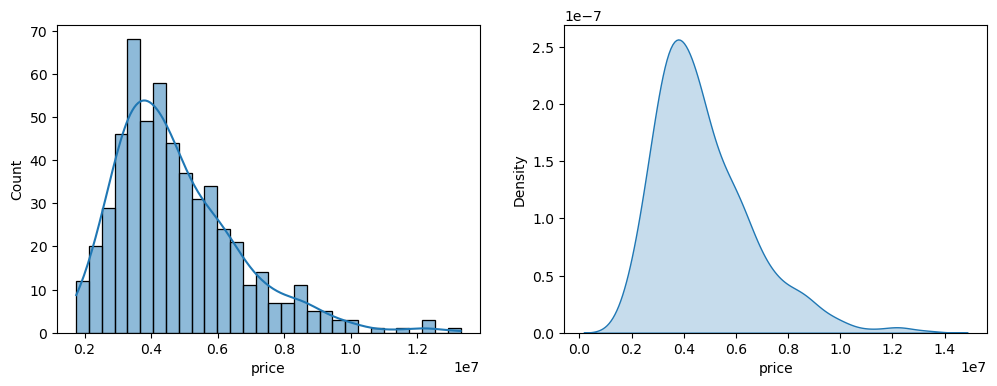

In [48]:
# 1. ГИСТОГРАММА + KDE (распределение price)
fig, axes = plt.subplots(1, 2, figsize=(12,4))
sns.histplot(df['price'], bins=30, kde=True, ax=axes[0])
sns.kdeplot(df['price'], fill=True, ax=axes[1])
plt.show()

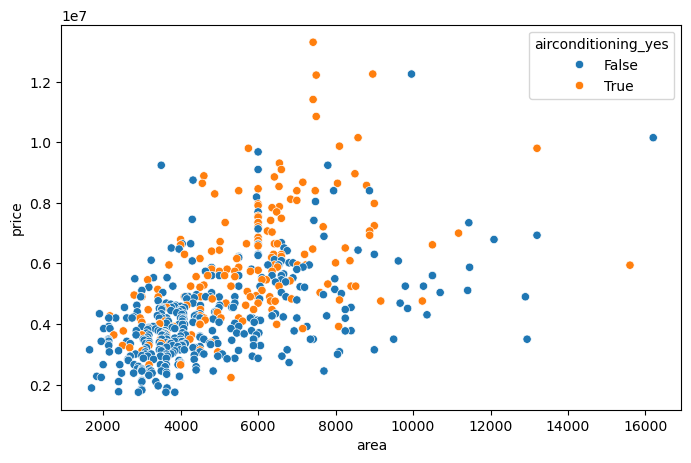

In [55]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='area', y='price', hue='airconditioning_yes')
plt.show()

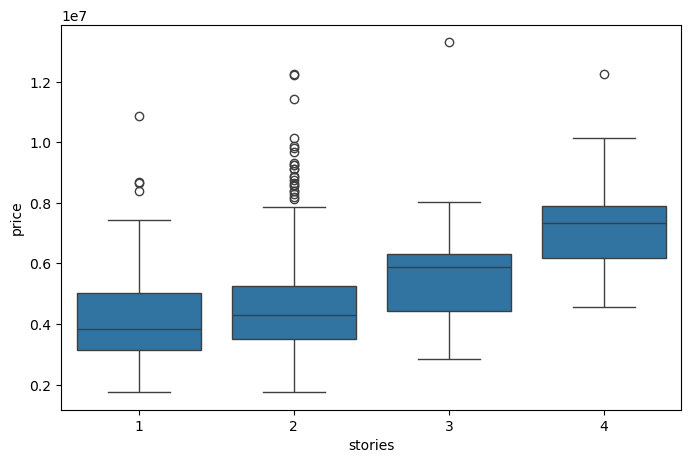

In [50]:
# 3. BOX PLOT (выбросы в price по этажности)
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='stories', y='price')
plt.show()

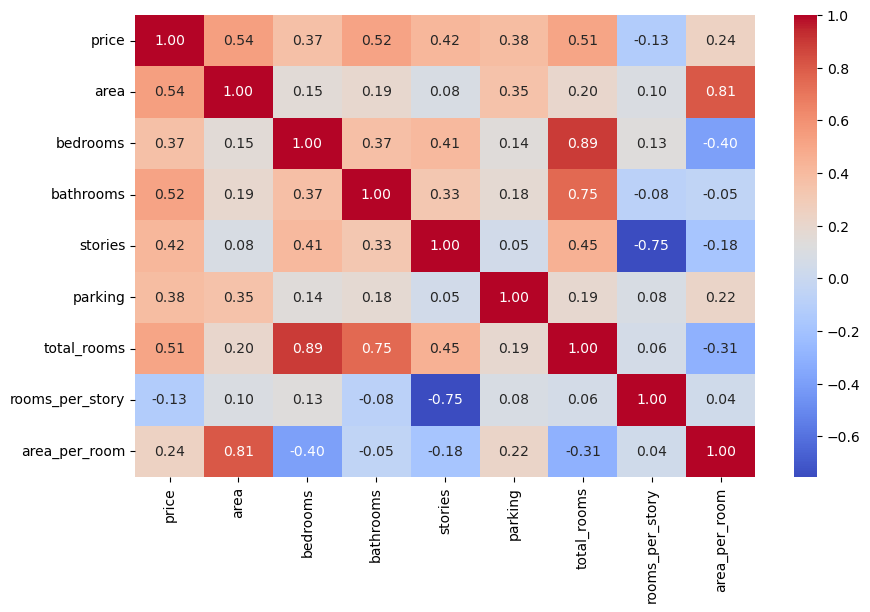

In [52]:
# 5. HEATMAP корреляций
plt.figure(figsize=(10,6))
corr = df.select_dtypes(include='number').corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.show()

In [53]:
# ВЫВОД по корреляции:
print("Сильная корреляция:")
print(f"area ↔ price: {corr['area']['price']:.2f}")
print(f"bedrooms ↔ bathrooms: {corr['bedrooms']['bathrooms']:.2f}")

Сильная корреляция:
area ↔ price: 0.54
bedrooms ↔ bathrooms: 0.37


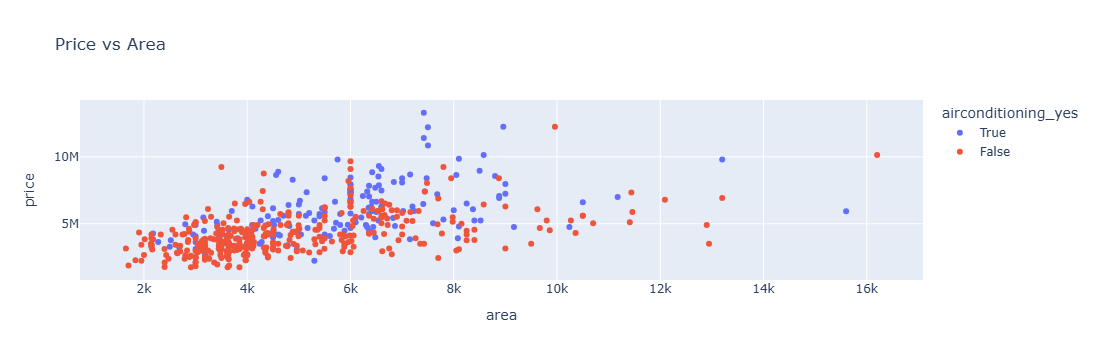

In [56]:
fig = px.scatter(df, x='area', y='price', color='airconditioning_yes',
                 hover_data=['bedrooms', 'stories', 'total_rooms'], 
                 title='Price vs Area')
fig.show()

- Цены на жилье имеют правостороннюю асимметрию (skewness > 1) — большинство домов дешевые, редкие особняки сильно дороже

- Площадь и цена умеренно коррелируют (0.54), но не линейно — есть разброс

- Данные чистые: нет пропусков, нет дубликатов

- Количество парковочных мест чаще всего 0, максимум 3

- Большинство домов имеют кондиционер (airconditioning_yes ~ 54%)

- Престижный район (prefarea_yes) встречается реже (~30% домов)

- Основная часть домов — 2 этажа (медиана), но есть до 4 этажей

- В датасете 6 числовых и 7 категориальных признаков

- Дисперсия по цене огромная (3.5e12) — нужно масштабирование

- Выбросы есть: 95-й перцентиль цены (8.4M) vs максимум (13.3M)

- bathrooms имеют сильную правостороннюю асимметрию (1.59) — чаще 1 ванная, редко 4

### Гипотезы
- Дома с кондиционером стоят дороже: на scatter plot виден разрыв между airconditioning_yes и no

- Выбросы по цене — это дома с большой площадью (>9000) + prestig+ кондиционер

- Престижный район дает наценку, но в данных только 30% таких домов — выборка смещена

- Количество ванных комнат сильнее коррелирует с ценой, чем количество спален

- bedrooms и bathrooms связаны, но не линейно (0.37) — люди с 2 спальнями могут иметь 1 или 2 ванные

